## SETUP & DATA LOADING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Set a professional visual style for all graphs
sns.set_style("whitegrid")
plt.rcParams.update({'figure.autolayout': True})

# Load the dataset cleaned by Member 1
# We rely on the engineered columns: year_month, season_name, time_of_day, etc.
df = pd.read_csv('Cleaned_data.csv')

# Ensure chronological order for time-series analysis
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print("Cleaned Dataset loaded successfully!")
print(f"Dataset Shape: {df.shape}")
display(df.head(3))

Cleaned Dataset loaded successfully!
Dataset Shape: (419040, 31)


,transaction_id,customer_id,product_id,product_name,category,timestamp,date,hour,day_of_week,month,...,temperature_celsius,feels_like_celsius,humidity_percent,windspeed_kmh,day_name,season_name,discounted_price,time_of_day,is_weekend,year_month
0,T0000001,C01357,P007,Salad Bowl,Meal,2011-01-01 00:08:00,2011-01-01,0,6,1,...,9.8,14.4,81.0,0.0,Saturday,Winter,8.50,Night,1,2011-01
1,T0000002,C01999,P003,Hot Chocolate,Beverage,2011-01-01 00:31:00,2011-01-01,0,6,1,...,9.8,14.4,81.0,0.0,Saturday,Winter,10.83,Night,1,2011-01
2,T0000003,C00629,P012,Smoothie,Beverage,2011-01-01 01:00:00,2011-01-01,1,6,1,...,9.0,13.6,80.0,0.0,Saturday,Winter,5.50,Night,1,2011-01


## MONTHLY SALES TREND

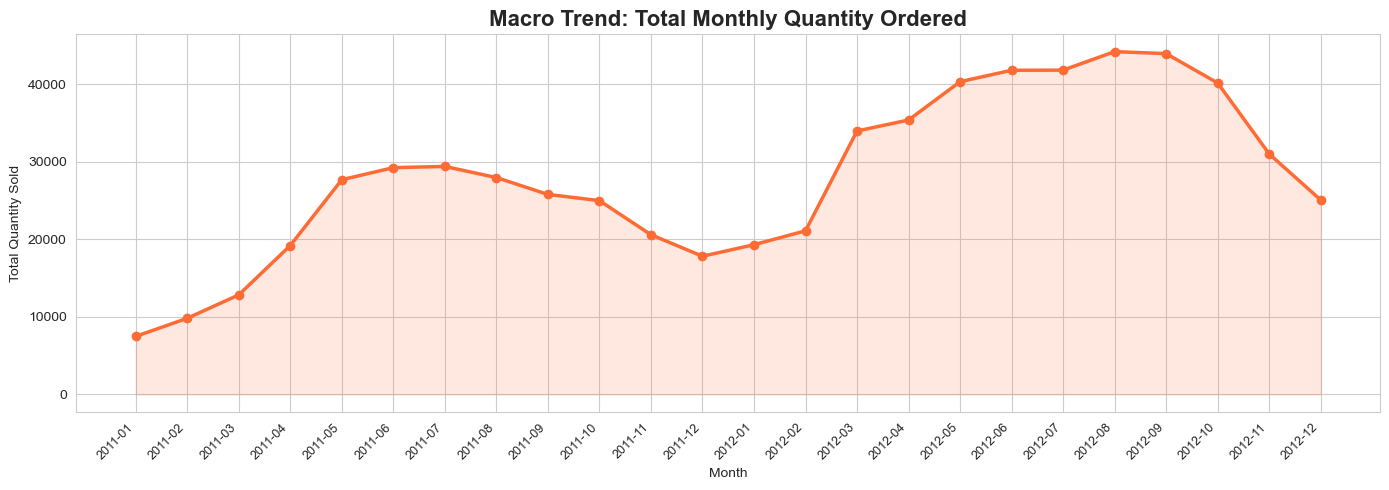

In [2]:
# Goal: Understand the macro-level sales volume over time.

monthly_orders = df.groupby('year_month')['quantity'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_orders['year_month'], monthly_orders['quantity'],
        color='#FF6B35', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(monthly_orders['year_month'], monthly_orders['quantity'],
                alpha=0.15, color='#FF6B35')

ax.set_xticks(range(len(monthly_orders['year_month'])))
ax.set_xticklabels(monthly_orders['year_month'], rotation=45, ha='right', fontsize=9)
ax.set_title('Macro Trend: Total Monthly Quantity Ordered', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Quantity Sold')

plt.show()

## TIME-SERIES DECOMPOSITION

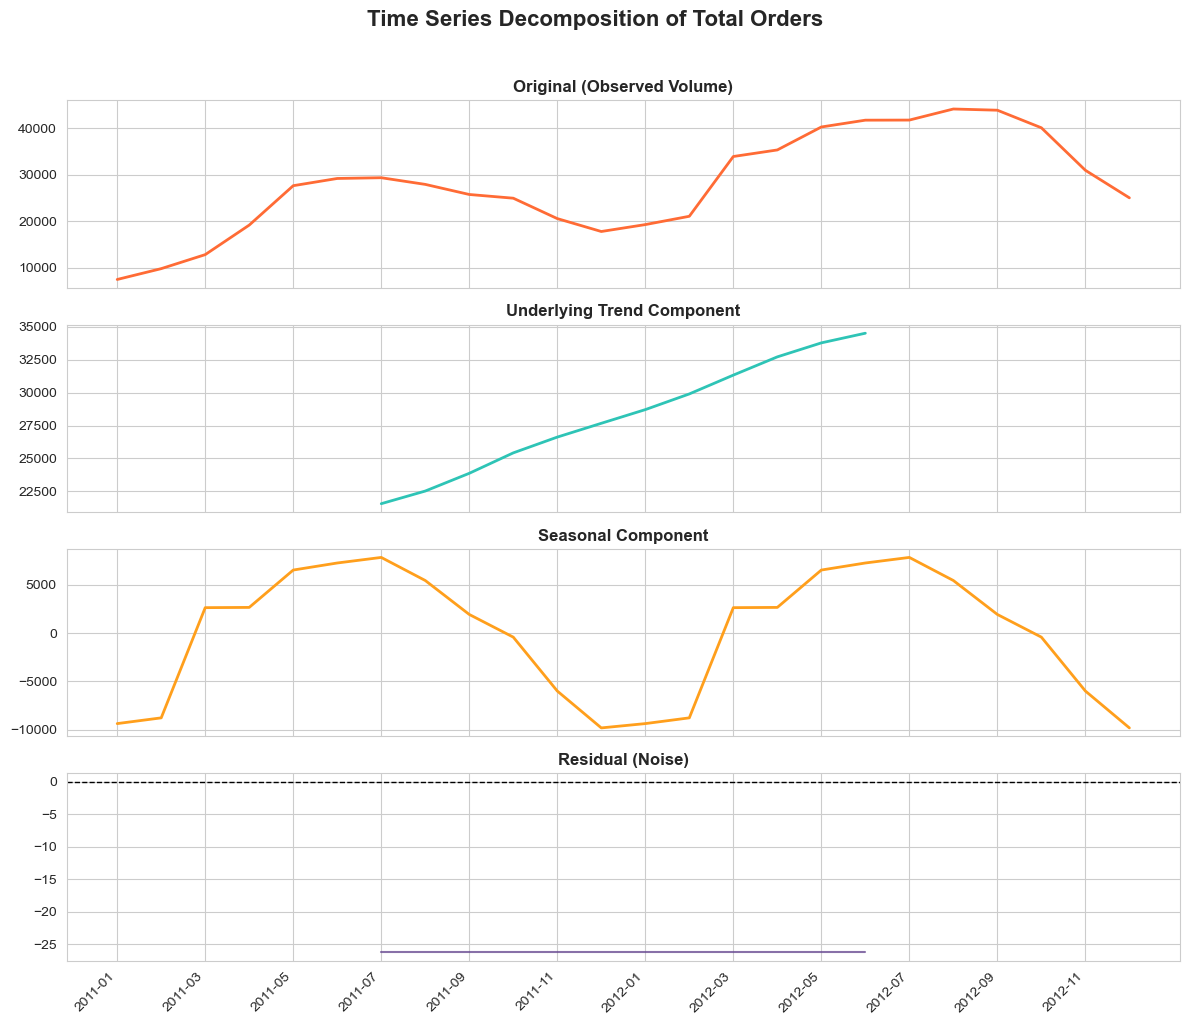

In [3]:
# Goal: Statistically separate the trend from the recurring seasonality.

# Create a time series object of monthly quantities
ts_data = df.groupby('year_month')['quantity'].sum()

# Decompose the time series (period=12 for annual seasonality in monthly data)
decomposition = seasonal_decompose(ts_data.values, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(ts_data.values, color='#FF6B35', linewidth=2)
axes[0].set_title('Original (Observed Volume)', fontsize=12, fontweight='bold')

axes[1].plot(decomposition.trend, color='#2EC4B6', linewidth=2)
axes[1].set_title('Underlying Trend Component', fontsize=12, fontweight='bold')

axes[2].plot(decomposition.seasonal, color='#FF9F1C', linewidth=2)
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')

axes[3].plot(decomposition.resid, color='#6A4C93', linewidth=1.5, alpha=0.8)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_title('Residual (Noise)', fontsize=12, fontweight='bold')

# Format x-axis for the bottom chart
step = max(1, len(ts_data)//10)
axes[3].set_xticks(range(0, len(ts_data), step))
axes[3].set_xticklabels(ts_data.index[::step], rotation=45, ha='right')

plt.suptitle('Time Series Decomposition of Total Orders', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## Top 10 Best-Selling Products

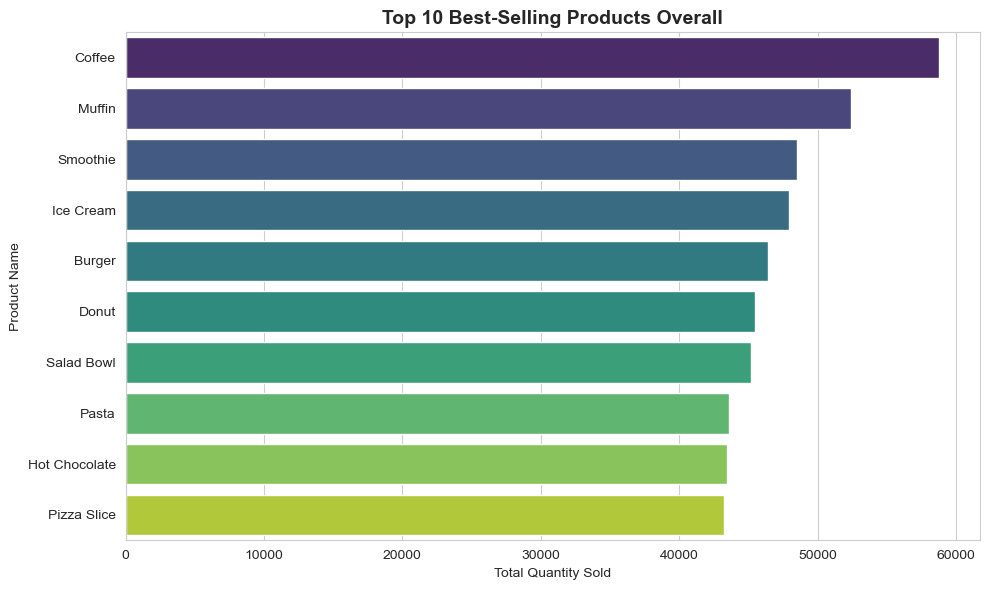

In [5]:
# Goal: Identify the exact products driving the most volume (The target for our ML).

top_10 = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
# FIX: Added hue and legend=False to comply with new Seaborn syntax
sns.barplot(x=top_10.values, y=top_10.index, hue=top_10.index, palette='viridis', legend=False, ax=ax)

ax.set_title('Top 10 Best-Selling Products Overall', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Quantity Sold')
ax.set_ylabel('Product Name')

plt.show()

## Category Distribution

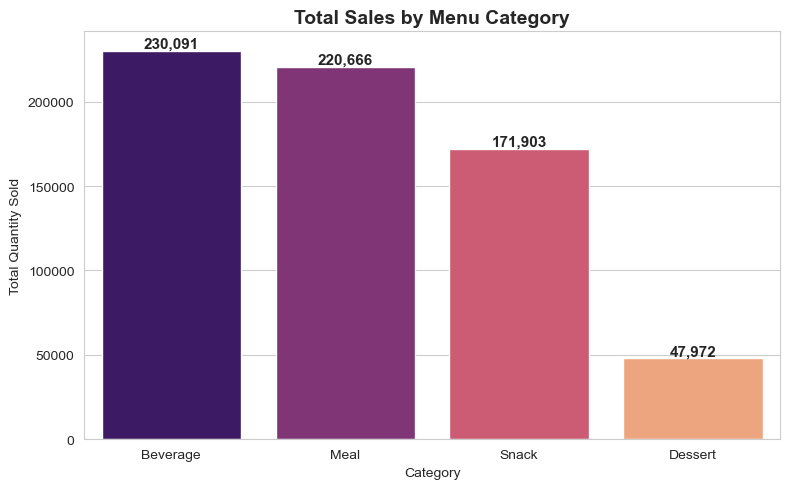

In [6]:
# Goal: See which macro-categories Swiggy should focus inventory on.

category_sales = df.groupby('category')['quantity'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
# FIX: Added hue and legend=False
sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette='magma', legend=False, ax=ax)

# Add numeric labels on top of the bars for easy reading in a presentation
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Total Sales by Menu Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Quantity Sold')

plt.show()

## Product Seasonality Analysis

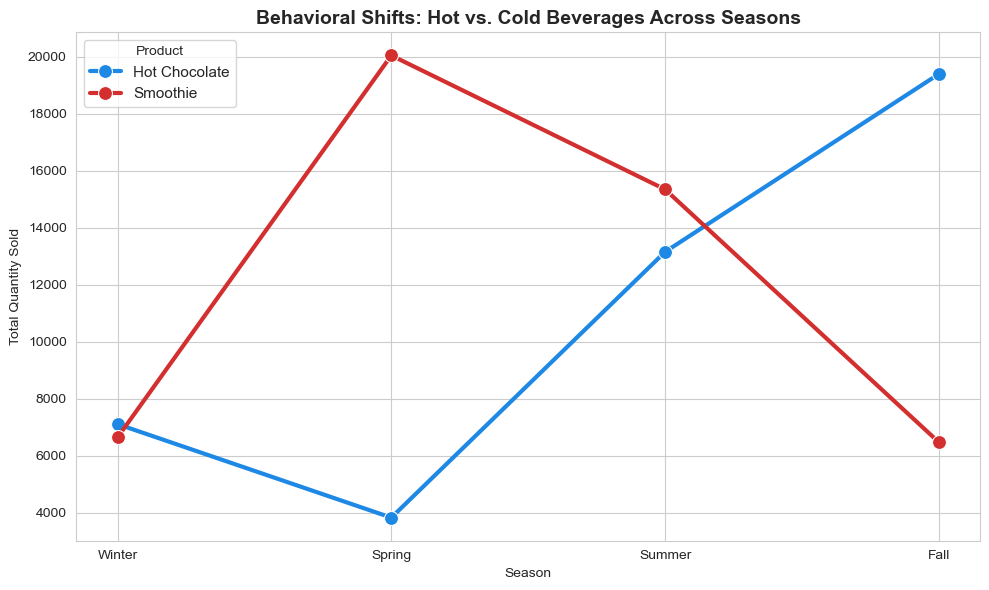

In [7]:
# Goal: Prove to the judges WHY our Machine Learning model needs weather/season features.

# Pick a distinctly "Cold" and "Hot" item from the dataset for contrast
# (Using actual products from our menu: Smoothie vs. Hot Chocolate)
contrasting_products = df[df['product_name'].isin(['Smoothie', 'Hot Chocolate'])]

seasonal_product_sales = contrasting_products.groupby(['season_name', 'product_name'])['quantity'].sum().reset_index()

# Ensure seasons display in chronological order, not alphabetical
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_product_sales['season_name'] = pd.Categorical(
    seasonal_product_sales['season_name'], 
    categories=season_order, 
    ordered=True
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=seasonal_product_sales, x='season_name', y='quantity', 
             hue='product_name', marker='o', linewidth=3, markersize=10, 
             palette=['#1E88E5', '#D32F2F'], ax=ax)

ax.set_title('Behavioral Shifts: Hot vs. Cold Beverages Across Seasons', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Total Quantity Sold')
plt.legend(title='Product', fontsize=11)

plt.show()